# Kaggle Compettion Notebook

- Author: Daniya Tur Rehman
- Linkedin: https://www.linkedin.com/in/daniya-tur-rehman/
- GitHub: https://github.com/DaniyaTR 

## __Survival Rate Predicted by Neural Network In Tensorflow__

In [1]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
# load the dataset
df_test=pd.read_csv('data/test.csv')
df_train=pd.read_csv('data/train.csv')
df_submission=pd.read_csv('data/gender_submission.csv')

In [3]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
df_submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


## Let's explore the data df_train.csv

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:

(df_train.isnull().sum() / len(df_train) * 100 ).sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

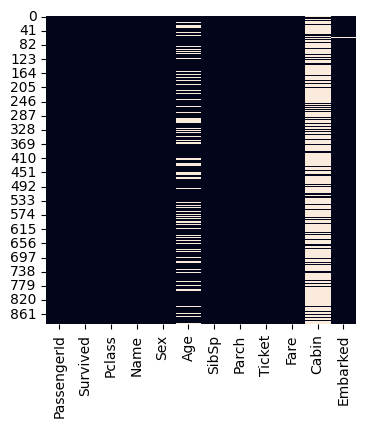

In [8]:
## plot the null values 
plt.figure(figsize=(4,4))
sns.heatmap(df_train.isnull(), cbar=False)
plt.show()

In [9]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [10]:
df = df_train.copy()

## Functions to impute missing values from df

In [11]:
# ================================
# IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, accuracy_score, r2_score, mean_squared_error
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# ================================
# DEFINE COLUMN TYPES
# ================================
categorical_cols = ['Cabin', 'Embarked']
bool_cols = []
numeric_cols = ['Age']

# Missing columns
missing_data_cols = df.isnull().sum()[df.isnull().sum() > 0].index.tolist()

# ================================
# FUNCTION: CATEGORICAL IMPUTATION
# ================================
def impute_categorical_missing_data(passed_col):

    df_null = df[df[passed_col].isnull()].copy()
    df_not_null = df[df[passed_col].notnull()].copy()

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]

    other_missing_cols = [col for col in missing_data_cols if col != passed_col]

    # Encode X
    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype.name == 'category':
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

    # Encode y if needed
    if passed_col in bool_cols or y.dtype == 'object':
        le_y = LabelEncoder()
        y = le_y.fit_transform(y.astype(str))

    # Imputer
    imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42))

    for col in other_missing_cols:
        if col in X.columns and X[col].isnull().sum() > 0:
            X[col] = imputer.fit_transform(X[[col]])

    # Train model
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(f"{passed_col} Accuracy: {round(accuracy_score(y_test, y_pred)*100,2)}%")

    # Predict missing values
    if len(df_null) > 0:
        X_null = df_null.drop(passed_col, axis=1)

        for col in X_null.columns:
            if X_null[col].dtype == 'object' or X_null[col].dtype.name == 'category':
                le = LabelEncoder()
                X_null[col] = le.fit_transform(X_null[col].astype(str))

        for col in other_missing_cols:
            if col in X_null.columns and X_null[col].isnull().sum() > 0:
                X_null[col] = imputer.fit_transform(X_null[[col]])

        df_null[passed_col] = model.predict(X_null)

    df_combined = pd.concat([df_not_null, df_null])
    return df_combined[passed_col]


# ================================
# FUNCTION: NUMERICAL IMPUTATION
# ================================
def impute_continuous_missing_data(passed_col):

    df_null = df[df[passed_col].isnull()].copy()
    df_not_null = df[df[passed_col].notnull()].copy()

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]

    other_missing_cols = [col for col in missing_data_cols if col != passed_col]

    # Encode X
    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype.name == 'category':
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

    # Imputer
    imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42))

    for col in other_missing_cols:
        if col in X.columns and X[col].isnull().sum() > 0:
            X[col] = imputer.fit_transform(X[[col]])

    # Train model
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(f"{passed_col} MAE:", mean_absolute_error(y_test, y_pred))
    print(f"{passed_col} RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))  # FIXED
    print(f"{passed_col} R2:", r2_score(y_test, y_pred))
    print()

    # Predict missing values
    if len(df_null) > 0:
        X_null = df_null.drop(passed_col, axis=1)

        for col in X_null.columns:
            if X_null[col].dtype == 'object' or X_null[col].dtype.name == 'category':
                le = LabelEncoder()
                X_null[col] = le.fit_transform(X_null[col].astype(str))

        for col in other_missing_cols:
            if col in X_null.columns and X_null[col].isnull().sum() > 0:
                X_null[col] = imputer.fit_transform(X_null[[col]])

        df_null[passed_col] = model.predict(X_null)

    df_combined = pd.concat([df_not_null, df_null])
    return df_combined[passed_col]


# ================================
# APPLY IMPUTATION
# ================================
for col in missing_data_cols:
    print(f"Missing Values {col}: {round((df[col].isnull().sum()/len(df))*100,2)}%")

    if col in categorical_cols:
        df[col] = impute_categorical_missing_data(col)

    elif col in numeric_cols:
        df[col] = impute_continuous_missing_data(col)

# ================================
# FINAL CHECK
# ================================
print("\nRemaining Missing %:")
print((df.isnull().sum() / len(df) * 100).sort_values(ascending=False))

Missing Values Age: 19.87%
Age MAE: 9.065764335664337
Age RMSE: 11.465017021792859
Age R2: 0.29102676844601394

Missing Values Cabin: 77.1%
Cabin Accuracy: 34.15%
Missing Values Embarked: 0.22%
Embarked Accuracy: 90.45%

Remaining Missing %:
PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Cabin          0.0
Embarked       0.0
dtype: float64


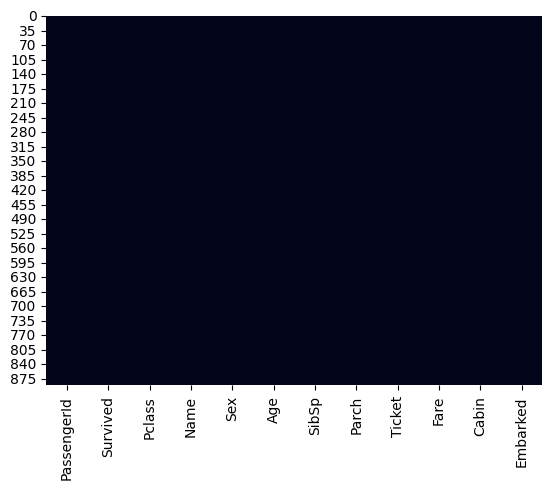

In [12]:
## Plot missing values 
sns.heatmap(df.isnull(), cbar=False)
plt.show()

Missing values have been imputed or removed from data set

In [14]:

# split the data into X and y
X = df.drop(['Survived', 'Name'], axis=1)
y = df['Survived']

# encode the data
label_encoder = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'category':
        X[col] = label_encoder.fit_transform(X[col].astype(str))
    else:
        pass
    
# split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
df_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [16]:
X_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
331,332,1,1,45.5,0,0,20,28.5000,85,3
733,734,2,1,23.0,0,0,228,13.0000,27,3
382,383,3,1,32.0,0,0,665,7.9250,3,3
704,705,3,1,26.0,1,0,398,7.8542,3,3
813,814,3,0,6.0,4,2,333,31.2750,16,3


## Create a Neural Network for Binary Classification

In [18]:
# use tensorflow to create a neural network
import tensorflow as tf

# Building the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu', 
                          input_shape=(X_train.shape[1],)), # Input layer
    tf.keras.layers.Dense(64, activation='relu'), # Hidden layer 1
    tf.keras.layers.Dense(32, activation='relu'), # Hidden layer 2
    tf.keras.layers.Dense(16, activation='relu'), # Hidden layer 3
    tf.keras.layers.Dense(8, activation='relu'), # Hidden layer 3
    
    tf.keras.layers.Dense(1, activation='sigmoid') # Output layer
])



## Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## Training the model
model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

## Evaluating the model on the test set
model.evaluate(X_test, y_test)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6236 - loss: 0.7239 - val_accuracy: 0.5866 - val_loss: 0.6916
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6222 - loss: 0.6904 - val_accuracy: 0.5866 - val_loss: 0.6903
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6236 - loss: 0.6880 - val_accuracy: 0.5866 - val_loss: 0.6890
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6236 - loss: 0.6862 - val_accuracy: 0.5866 - val_loss: 0.6877
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6236 - loss: 0.6844 - val_accuracy: 0.5866 - val_loss: 0.6867
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6236 - loss: 0.6829 - val_accuracy: 0.5866 - val_loss: 0.6855
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6236 - loss: 0.6812 - val_accuracy: 0.5866 - val_loss: 0.6848
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6236 - loss: 0.6799 - val_accuracy: 0.5866

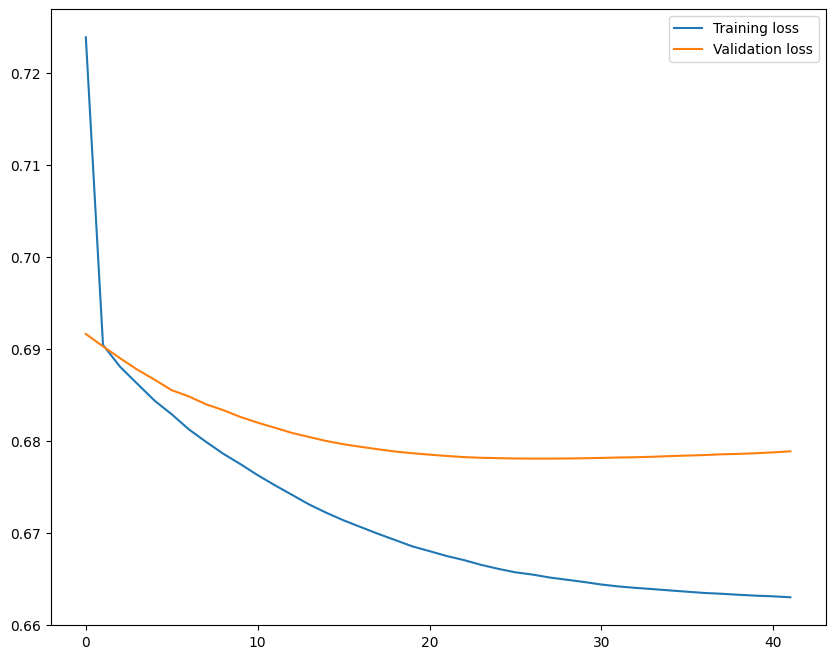

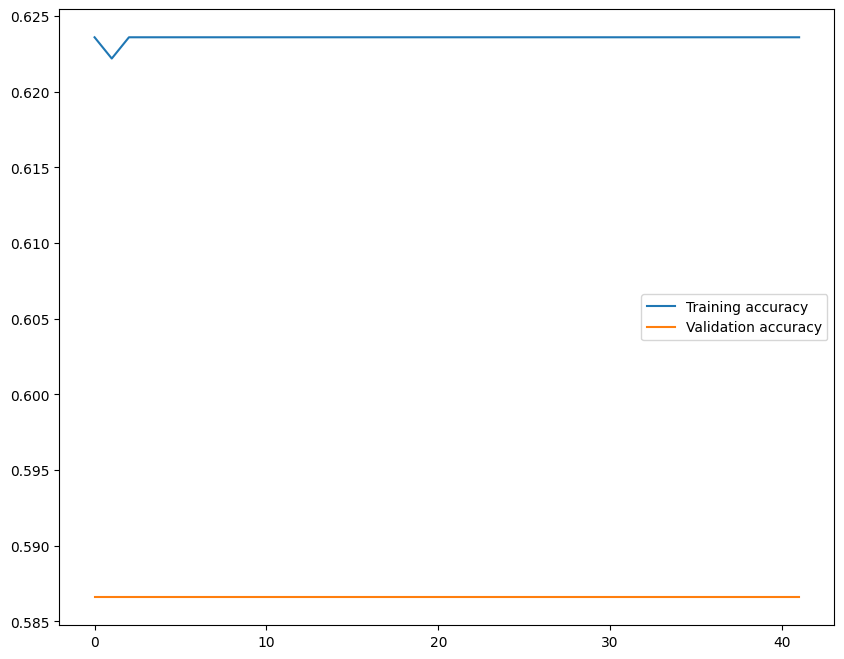

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the callback function
early_stopping = EarlyStopping(patience=15)


# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# train the model and plot the training and testing loss and accuracy at each epoc
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1, validation_data=(X_test, y_test), 
                    callbacks=[early_stopping])

# plot the training and testing loss and accuracy at each epoc
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(history.history['loss'], label='Training loss')
ax.plot(history.history['val_loss'], label='Validation loss')
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(history.history['accuracy'], label='Training accuracy')
ax.plot(history.history['val_accuracy'], label='Validation accuracy')
ax.legend()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step


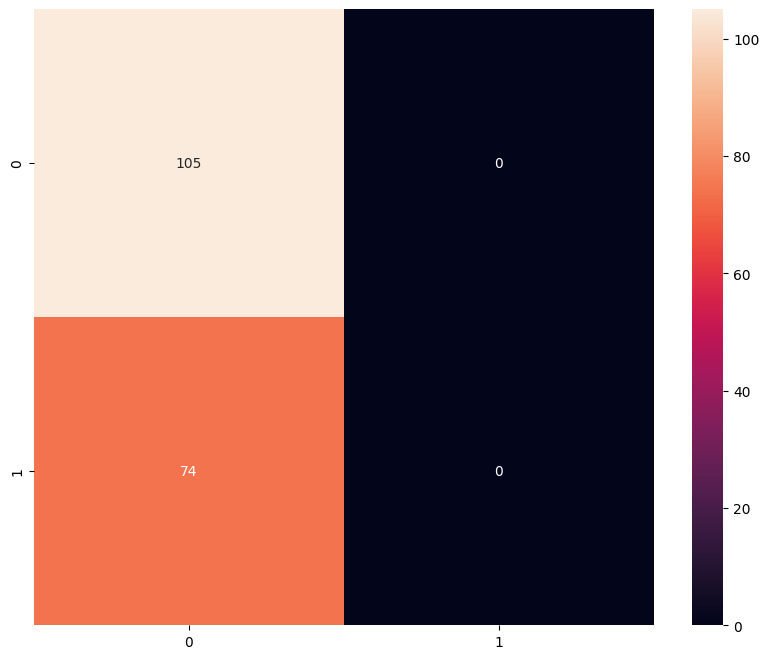

In [20]:
# create a confusion matrix
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)

# plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g')
plt.show()

In [22]:
# creata a submission file
X_submission = df_test.drop('Name', axis=1)

for col in X_submission.columns:
    if X_submission[col].dtype == 'object' or X_submission[col].dtype == 'category':
        X_submission[col] = label_encoder.fit_transform(X_submission[col])
    else:
        pass
    
y_submission = model.predict(X_submission)
y_submission = (y_submission > 0.5)

df_submission['Survived'] = y_submission.astype(int)

df_submission.to_csv('data/submission.csv', index=False)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
